Title: 7_day_comp.ipynb

Purpose: Analyse the weekly distributions from the ERA5, CMIP6 and importance sampling data

Author: Onno Nennecke on 21.04.2026 Modified: 21.04.2026

Input data: 

- Adjusted Model output: model_output_adj.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'

Output data:

- Plots: 2D_hist, Return_period_plot
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

import seaborn as sns

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ds.load()

ts_datasets = ds.where(ds.ESM_run != 'SMARD_hist',drop=True)
ts_datasets.load()

ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week',drop=True)
ds_ERA5.load()


<xarray.Dataset> Size: 365kB
Dimensions:        (ESM_run: 1, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 52B 'ERA5_week'
    run            (ESM_run) <U12 48B 'hist'
  * ESM_run        (ESM_run) <U23 92B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         (ESM_run) <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 29kB 1.323 3.335 ... 0.7396 0.4142
    demand         (ESM_run, time) float64 29kB 1.504e+03 ... 1.515e+03
    sfcWind        (ESM_run, time) float64 29kB 7.507 11.86 ... 8.049 8.775
    rsds           (ESM_run, time) float32 15kB 30.54 19.51 17.85 ... 26.3 31.92
    tas            (ESM_run, time) float32 15kB 1.771 3.587 ... 1.512 1.194
    tasmax         (ESM_run, time) float32 15kB 3.431 5.871 ... 2.709 3.361
    wind_off_prod  (ESM_run, time) float64 29kB 220.8 221.2 ... 221.1 221.1
    wind_on_prod   (ESM_run, time) float64 29kB 695.5 1.357e+03 ... 783.9 831.2
    solar_prod     (ESM_run, time) float64 29kB 53.72 25.34 ... 48.64 59.86
    total_prod     (ESM_run, time) float64 29kB 970.0 1.603e+03 ... 1.112e+03
    Netto          (ESM_run, time) float64 29kB -533.6 124.7 ... -457.1 -402.6
    Residual_load  (ESM_run, time) float64 29kB 533.6 -124.7 ... 457.1 402.6

In [3]:
path = '/climca/people/onennecke/model_output/REA/*.nc'
files = [x for x in glob.glob(path) if x.endswith('.nc')]

ds_REA = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ds_REA

<xarray.Dataset> Size: 2MB
Dimensions:        (ESM_run: 126, time: 154)
Coordinates:
    sim            (ESM_run) <U90 45kB 'c2.033.031.029.027.028.033.035.038.03...
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            (ESM_run) <U6 3kB 'ens058' 'ens056' ... 'ens032' 'ens087'
  * ESM_run        (ESM_run) <U19 10kB 'CESM2_LE_REA_ens058' ... 'CESM2_LE_RE...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    demand         (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    rsds           (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    tas            (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    tasmax         (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    Netto          (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>

In [4]:
not_winter = np.repeat(0, 183)

season = np.concatenate(
    [np.repeat(1, 90)] +
    [arr
        for i in range(2, 11)
        for arr in (not_winter, np.repeat(i, 182))
    ] +
    [not_winter, np.repeat(11, 92)]
)
print(len(season))

3650


In [5]:
ts_datasets= ts_datasets.assign_coords(season=("time", season))

In [11]:
# Select all data in the winter season (season != 0)
winter_data = ts_datasets.where(ts_datasets.season != 0, drop=True)
winter_data.load()


<xarray.Dataset> Size: 30MB
Dimensions:        (ESM_run: 193, time: 1820)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 15kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week'
    doy            (time) int64 15kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
    season         (time) int64 15kB 1 1 1 1 1 1 1 1 ... 11 11 11 11 11 11 11 11
Data variables:
    temp           (ESM_run, time) float64 3MB 2.862 -0.3492 ... -8.134 -9.41
    demand         (ESM_run, time) float64 3MB 1.485e+03 1.524e+03 ... 1.636e+03
    sfcWind        (ESM_run, time) float64 3MB 8.056 6.177 6.451 ... 3.01 4.735
    rsds           (ESM_run, time) float32 1MB 13.75 24.11 38.15 ... 38.66 48.7
    tas            (ESM_run, time) float32 1MB 2.114 -0.7924 ... -7.047 -8.388
    tasmax         (ESM_run, time) float32 1MB 4.033 0.7523 ... -3.341 -4.217
    wind_off_prod  (ESM_run, time) float64 3MB 122.3 158.7 129.4 ... 9.998 79.37
    wind_on_prod   (ESM_run, time) float64 3MB 731.3 532.7 450.6 ... 31.44 148.9
    solar_prod     (ESM_run, time) float64 3MB 21.42 39.42 66.29 ... 71.95 87.86
    total_prod     (ESM_run, time) float64 3MB 875.0 730.8 646.3 ... 113.4 316.1
    Netto          (ESM_run, time) float64 3MB -609.5 -793.4 ... -1.32e+03
    Residual_load  (ESM_run, time) float64 3MB 609.5 793.4 ... 1.32e+03

In [12]:
ds_REA

<xarray.Dataset> Size: 2MB
Dimensions:        (ESM_run: 126, time: 154)
Coordinates:
    sim            (ESM_run) <U90 45kB 'c2.033.031.029.027.028.033.035.038.03...
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            (ESM_run) <U6 3kB 'ens058' 'ens056' ... 'ens032' 'ens087'
  * ESM_run        (ESM_run) <U19 10kB 'CESM2_LE_REA_ens058' ... 'CESM2_LE_RE...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    demand         (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    rsds           (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    tas            (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    tasmax         (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    Netto          (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>

In [13]:
# Calculate the a 7-day rolling mean for the winter season
ts_datasets_7d = winter_data.rolling(time=7, center=True).mean()
ds_REA_7d = ds_REA.rolling(time=7, center=True).mean()

In [15]:
ds_REA_7d

<xarray.Dataset> Size: 2MB
Dimensions:        (ESM_run: 126, time: 154)
Coordinates:
    sim            (ESM_run) <U90 45kB 'c2.033.031.029.027.028.033.035.038.03...
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            (ESM_run) <U6 3kB 'ens058' 'ens056' ... 'ens032' 'ens087'
  * ESM_run        (ESM_run) <U19 10kB 'CESM2_LE_REA_ens058' ... 'CESM2_LE_RE...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    demand         (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    rsds           (ESM_run, time) float32 78kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    tas            (ESM_run, time) float32 78kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    tasmax         (ESM_run, time) float32 78kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    Netto          (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 153), meta=np.ndarray>

In [14]:
ts_datasets_7d

<xarray.Dataset> Size: 30MB
Dimensions:        (time: 1820, ESM_run: 193)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 15kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week'
    doy            (time) int64 15kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
    season         (time) int64 15kB 1 1 1 1 1 1 1 1 ... 11 11 11 11 11 11 11 11
Data variables:
    temp           (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    demand         (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    sfcWind        (ESM_run, time) float64 3MB nan nan nan 5.879 ... nan nan nan
    rsds           (ESM_run, time) float32 1MB nan nan nan 25.37 ... nan nan nan
    tas            (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    tasmax         (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    wind_off_prod  (ESM_run, time) float64 3MB nan nan nan 97.29 ... nan nan nan
    wind_on_prod   (ESM_run, time) float64 3MB nan nan nan 357.3 ... nan nan nan
    solar_prod     (ESM_run, time) float64 3MB nan nan nan 43.04 ... nan nan nan
    total_prod     (ESM_run, time) float64 3MB nan nan nan 497.7 ... nan nan nan
    Netto          (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    Residual_load  (ESM_run, time) float64 3MB nan nan nan ... nan nan nan

In [22]:
df_REA = ds_REA_7d.to_dataframe().reset_index()
df_REA
# Remove sim column
df_REA = df_REA.drop(columns=['sim'])
# Remove rows with NaN values
df_REA = df_REA.dropna()


df_REA

,ESM_run,time,crs,gridtype,ESM,run,country,period,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,solar_prod,total_prod,Netto,Residual_load
3,CESM2_LE_REA_ens058,2025-10-05,4326,lonlat,CESM2_LE_REA,ens058,9.0,week,11.393437,1373.585805,4.966271,75.874161,11.261353,15.848078,74.297336,204.021074,128.058179,406.376589,-967.209216,967.209216
4,CESM2_LE_REA_ens058,2025-10-06,4326,lonlat,CESM2_LE_REA,ens058,9.0,week,11.256828,1375.466477,5.173876,72.545311,11.167020,15.558785,83.026016,217.876262,122.858228,423.760506,-951.705971,951.705971
5,CESM2_LE_REA_ens058,2025-10-07,4326,lonlat,CESM2_LE_REA,ens058,9.0,week,10.856253,1380.947520,5.362165,67.203903,10.901219,14.835921,89.291685,223.974828,112.401807,425.668320,-955.279199,955.279199
6,CESM2_LE_REA_ens058,2025-10-08,4326,lonlat,CESM2_LE_REA,ens058,9.0,week,10.339121,1387.982692,5.632806,62.736641,10.532434,14.102396,96.463058,234.480112,102.751706,433.694875,-954.287817,954.287817
7,CESM2_LE_REA_ens058,2025-10-09,4326,lonlat,CESM2_LE_REA,ens058,9.0,week,9.999543,1392.615892,5.713836,55.892769,10.278548,13.445016,107.801620,255.802488,90.477191,454.081299,-938.534592,938.534592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19396,CESM2_LE_REA_ens087,2026-02-25,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,11.975747,1366.778923,4.651423,178.022995,11.240837,16.194607,12.717112,150.598243,270.093220,433.408575,-933.370348,933.370348
19397,CESM2_LE_REA_ens087,2026-02-26,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,12.112254,1365.725190,4.283302,186.667191,11.338087,16.513792,12.048291,135.120039,285.993631,433.161961,-932.563228,932.563228
19398,CESM2_LE_REA_ens087,2026-02-27,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,12.661244,1359.360239,4.012197,200.293945,11.809941,17.221928,10.926213,109.111314,309.491096,429.528622,-929.831617,929.831617
19399,CESM2_LE_REA_ens087,2026-02-28,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,12.862128,1356.668070,4.571168,187.554535,12.005120,17.289616,36.513007,214.806628,288.833400,540.153035,-816.515036,816.515036


In [24]:
19404 - 18648
756 / 6

126.0

In [19]:
df_REA['Residual_load'].max()

np.float64(1416.3976366703987)

In [25]:
df = ts_datasets_7d.to_dataframe().reset_index()
df = df.dropna()

df

,time,ESM_run,crs,gridtype,ESM,run,country,period,doy,season,...,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,solar_prod,total_prod,Netto,Residual_load
579,2015-01-04,ACCESS-CM2_r1i1p1f1,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,4,1,...,5.879329,25.368927,-0.799364,0.934487,97.290596,357.317645,43.044689,497.652930,-1033.952413,1033.952413
580,2015-01-04,ACCESS-CM2_r4i1p1f1,4326,lonlat,ACCESS-CM2,r4i1p1f1,9.0,week,4,1,...,6.116365,24.334673,2.759454,4.294721,125.099262,449.093831,42.686931,616.880024,-875.002547,875.002547
581,2015-01-04,ACCESS-CM2_r5i1p1f1,4326,lonlat,ACCESS-CM2,r5i1p1f1,9.0,week,4,1,...,5.097386,25.625986,0.667801,1.943684,77.576438,285.517033,45.102624,408.196095,-1109.279419,1109.279419
582,2015-01-04,BCC-CSM2-MR_r1i1p1f1,4326,lonlat,BCC-CSM2-MR,r1i1p1f1,9.0,week,4,1,...,6.439823,24.010344,5.243317,7.063500,66.978345,265.753824,41.407400,374.139569,-1082.048736,1082.048736
583,2015-01-04,CESM2_LE2-1001_001,4326,lonlat,CESM2,LE2-1001_001,9.0,week,4,1,...,4.507554,21.517885,4.356565,5.842502,67.809374,160.688640,35.244505,263.742519,-1205.668569,1205.668569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350676,2024-12-28,UKESM1-0-LL_r4i1p1f2,4326,lonlat,UKESM1-0-LL,r4i1p1f2,9.0,week,362,11,...,3.856298,26.357412,1.818617,3.633013,35.827078,133.100558,46.796148,215.723784,-1288.936747,1288.936747
350677,2024-12-28,UKESM1-0-LL_r5i1p1f2,4326,lonlat,UKESM1-0-LL,r5i1p1f2,9.0,week,362,11,...,6.785713,33.782444,-1.239281,1.665356,173.701725,555.492867,62.074977,791.269570,-750.248730,750.248730
350678,2024-12-28,UKESM1-0-LL_r6i1p1f2,4326,lonlat,UKESM1-0-LL,r6i1p1f2,9.0,week,362,11,...,6.965029,20.616468,5.662870,7.079465,120.942865,617.003887,35.110671,773.057424,-677.964008,677.964008
350679,2024-12-28,UKESM1-0-LL_r7i1p1f2,4326,lonlat,UKESM1-0-LL,r7i1p1f2,9.0,week,362,11,...,6.771792,23.382586,0.215988,1.816090,99.223475,557.677039,40.780455,697.680970,-825.872704,825.872704


In [27]:
2249-2123

126

In [26]:
# Combine the two dataframes
df_combined = pd.concat([df, df_REA], ignore_index=True)
df_combined

,time,ESM_run,crs,gridtype,ESM,run,country,period,doy,season,...,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,solar_prod,total_prod,Netto,Residual_load
0,2015-01-04,ACCESS-CM2_r1i1p1f1,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,4.0,1.0,...,5.879329,25.368927,-0.799364,0.934487,97.290596,357.317645,43.044689,497.652930,-1033.952413,1033.952413
1,2015-01-04,ACCESS-CM2_r4i1p1f1,4326,lonlat,ACCESS-CM2,r4i1p1f1,9.0,week,4.0,1.0,...,6.116365,24.334673,2.759454,4.294721,125.099262,449.093831,42.686931,616.880024,-875.002547,875.002547
2,2015-01-04,ACCESS-CM2_r5i1p1f1,4326,lonlat,ACCESS-CM2,r5i1p1f1,9.0,week,4.0,1.0,...,5.097386,25.625986,0.667801,1.943684,77.576438,285.517033,45.102624,408.196095,-1109.279419,1109.279419
3,2015-01-04,BCC-CSM2-MR_r1i1p1f1,4326,lonlat,BCC-CSM2-MR,r1i1p1f1,9.0,week,4.0,1.0,...,6.439823,24.010344,5.243317,7.063500,66.978345,265.753824,41.407400,374.139569,-1082.048736,1082.048736
4,2015-01-04,CESM2_LE2-1001_001,4326,lonlat,CESM2,LE2-1001_001,9.0,week,4.0,1.0,...,4.507554,21.517885,4.356565,5.842502,67.809374,160.688640,35.244505,263.742519,-1205.668569,1205.668569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368745,2026-02-25,CESM2_LE_REA_ens087,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,NaN,NaN,...,4.651423,178.022995,11.240837,16.194607,12.717112,150.598243,270.093220,433.408575,-933.370348,933.370348
368746,2026-02-26,CESM2_LE_REA_ens087,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,NaN,NaN,...,4.283302,186.667191,11.338087,16.513792,12.048291,135.120039,285.993631,433.161961,-932.563228,932.563228
368747,2026-02-27,CESM2_LE_REA_ens087,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,NaN,NaN,...,4.012197,200.293945,11.809941,17.221928,10.926213,109.111314,309.491096,429.528622,-929.831617,929.831617
368748,2026-02-28,CESM2_LE_REA_ens087,4326,lonlat,CESM2_LE_REA,ens087,9.0,week,NaN,NaN,...,4.571168,187.554535,12.005120,17.289616,36.513007,214.806628,288.833400,540.153035,-816.515036,816.515036


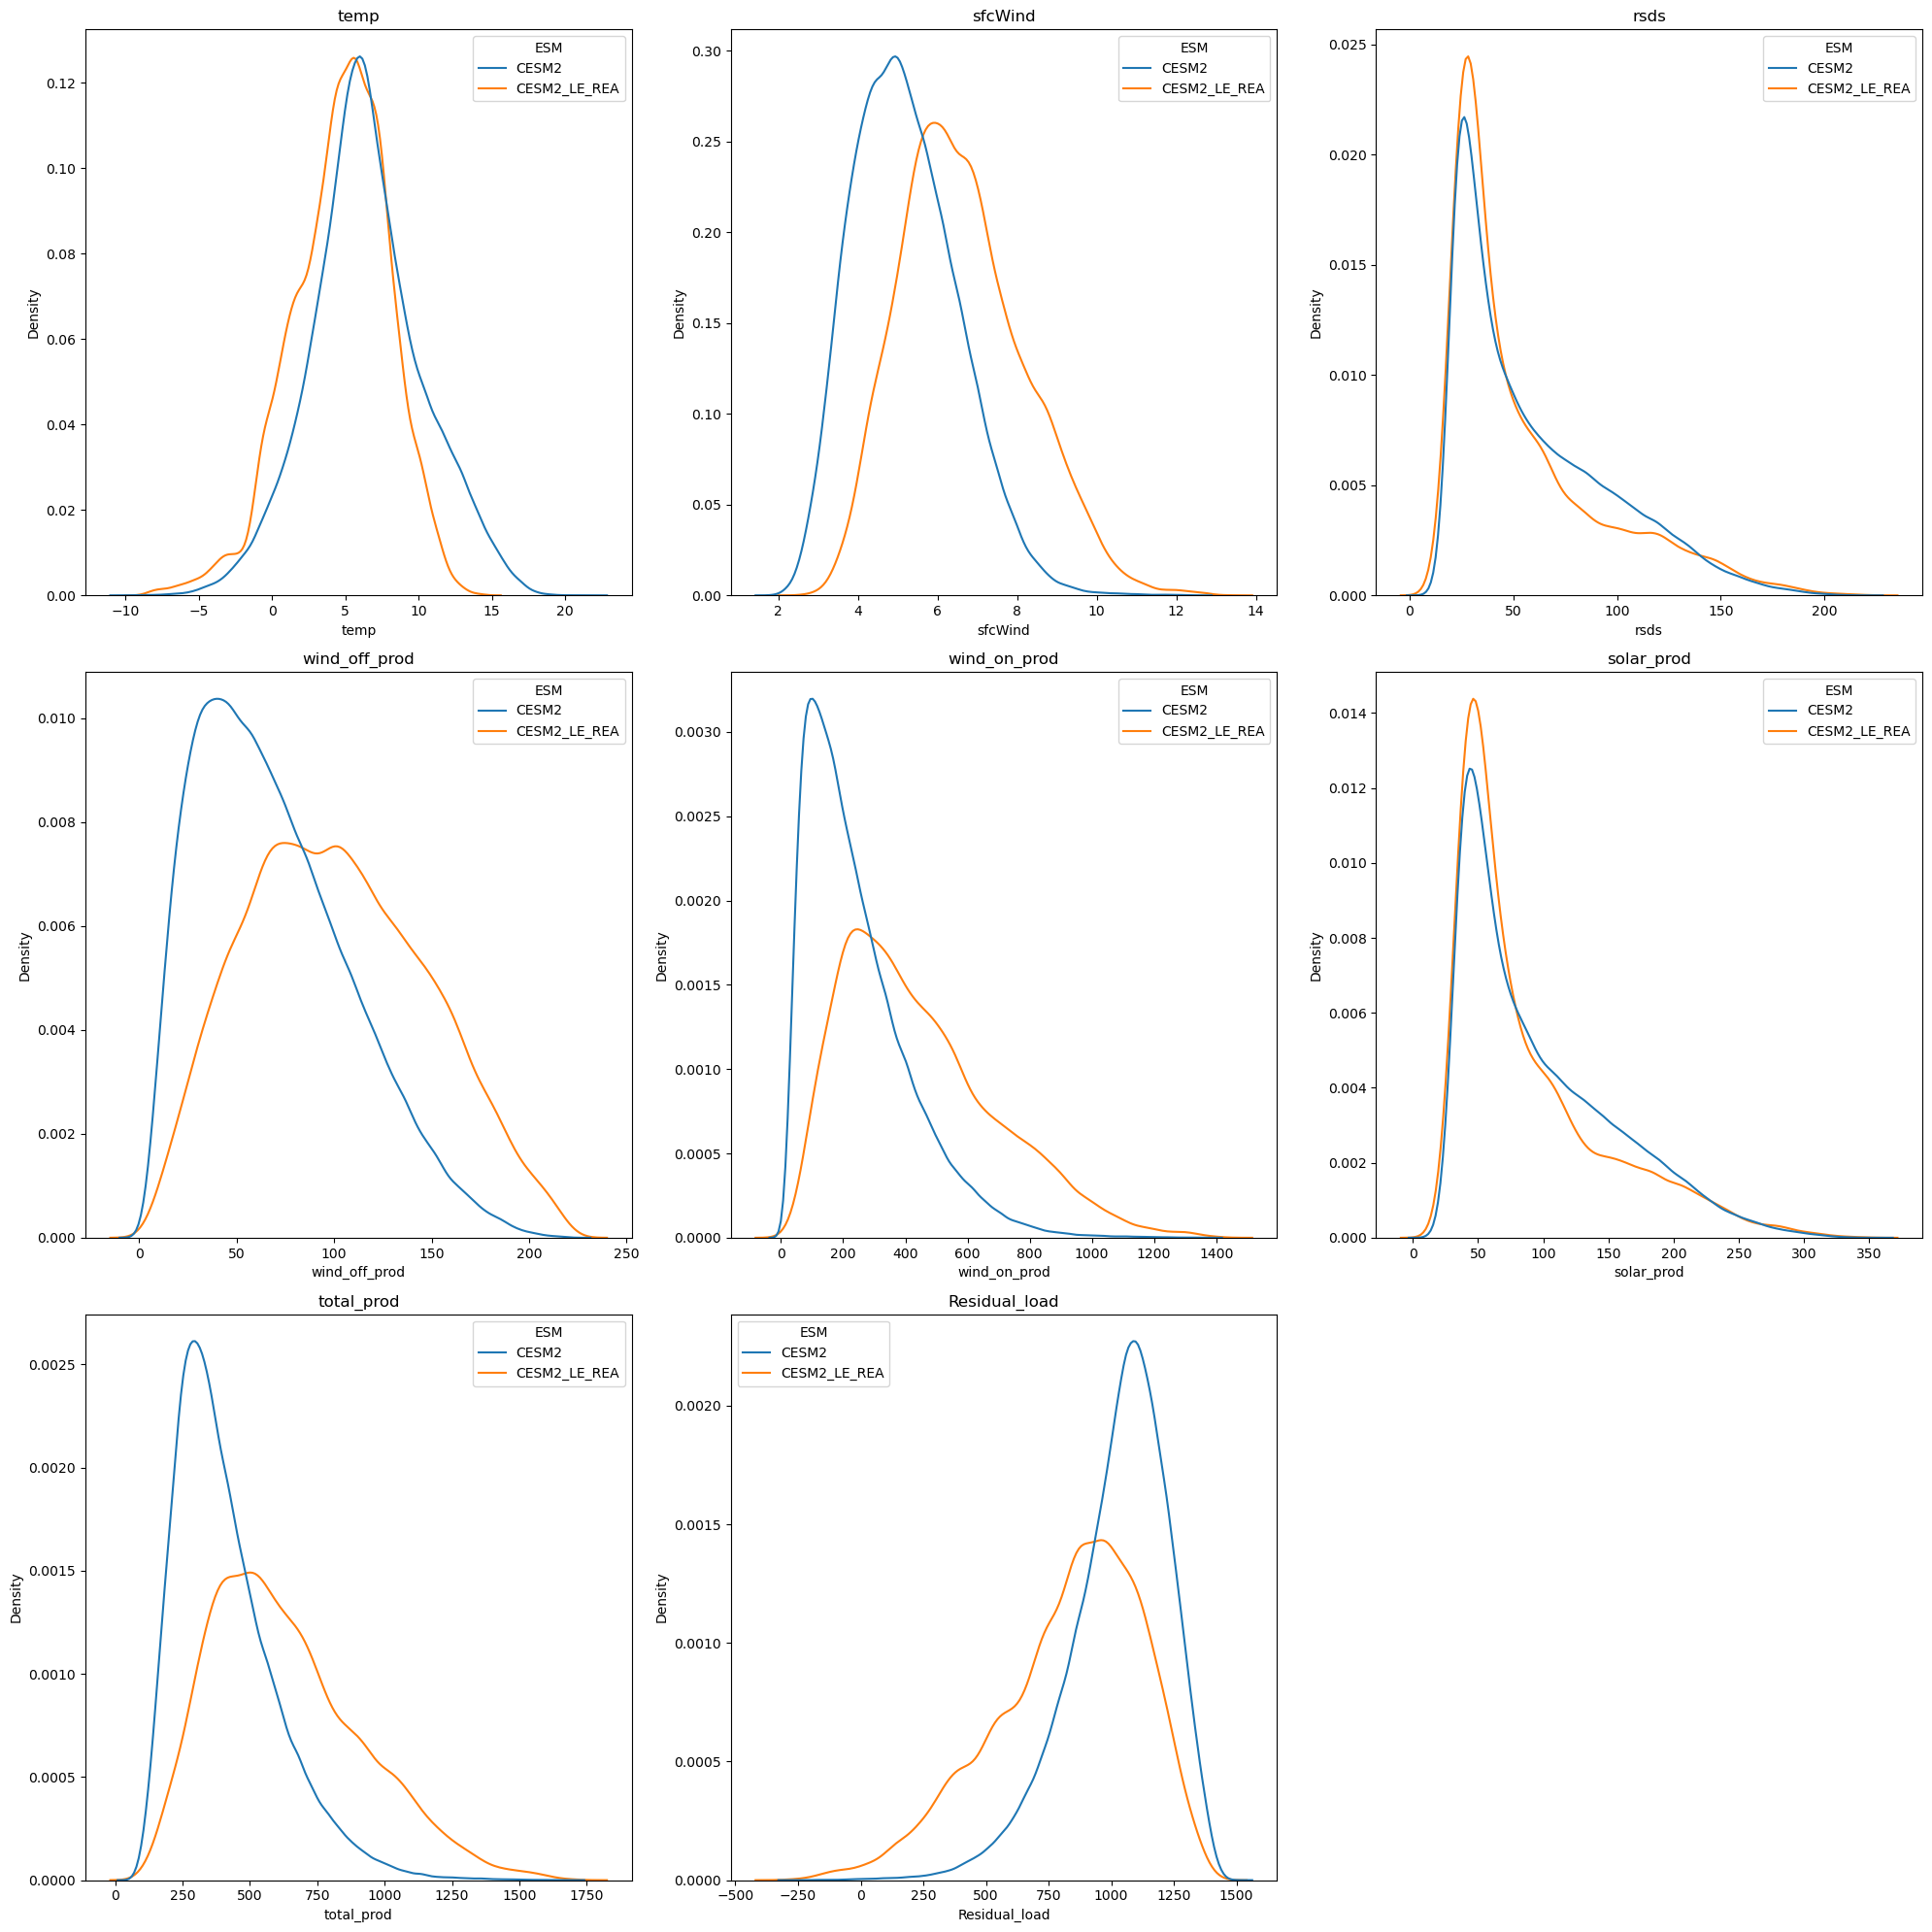

In [27]:
variables = ['temp', 'sfcWind', 'rsds', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load']

# Make a big plot with all variables
plt.figure(figsize=(20, 20))
for i, var in enumerate(variables):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(
        data=df_combined[(df_combined['ESM'] == 'CESM2') | (df_combined['ESM'] == 'CESM2_LE_REA')],
        x=var,
        hue="ESM",
        common_norm=False
    )
    plt.title(var)
plt.tight_layout()
plt.show()

In [61]:
21*1488

31248

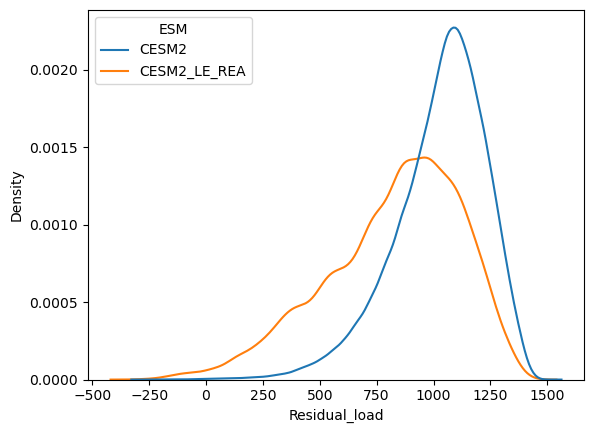

In [28]:
plt.figure()
sns.kdeplot(
    data=df_combined[(df_combined['ESM'] == 'CESM2') | (df_combined['ESM'] == 'CESM2_LE_REA')],
    x="Residual_load",
    hue="ESM",
    common_norm=False
)

plt.show()

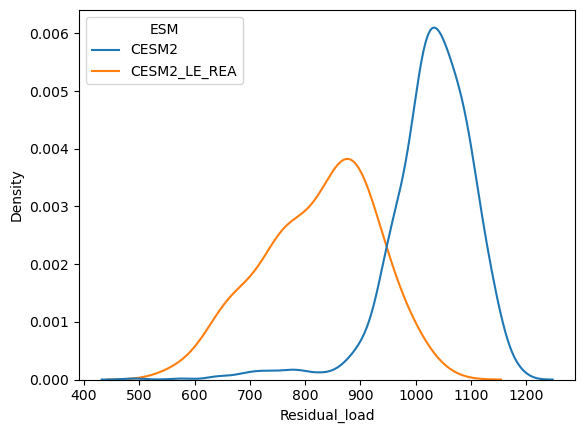

In [57]:
plt.figure()
sns.kdeplot(
    data=df_combined[(df_combined['ESM'] == 'CESM2') | (df_combined['ESM'] == 'CESM2_LE_REA')],
    x="Residual_load",
    hue="ESM",
    common_norm=False
)

plt.show()

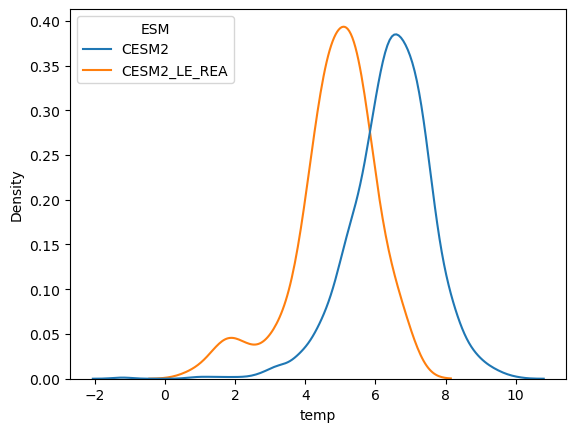

In [58]:
plt.figure()
sns.kdeplot(
    data=df_combined[(df_combined['ESM'] == 'CESM2') | (df_combined['ESM'] == 'CESM2_LE_REA')],
    x="temp",
    hue="ESM",
    common_norm=False
)

plt.show()

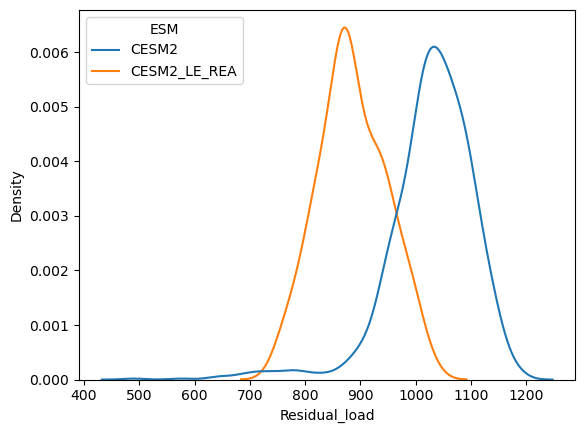

In [61]:
plt.figure()
sns.kdeplot(
    data=df_combined[(df_combined['ESM'] == 'CESM2') | (df_combined['ESM'] == 'CESM2_LE_REA')],
    x="Residual_load",
    hue="ESM",
    common_norm=False
)

plt.show()

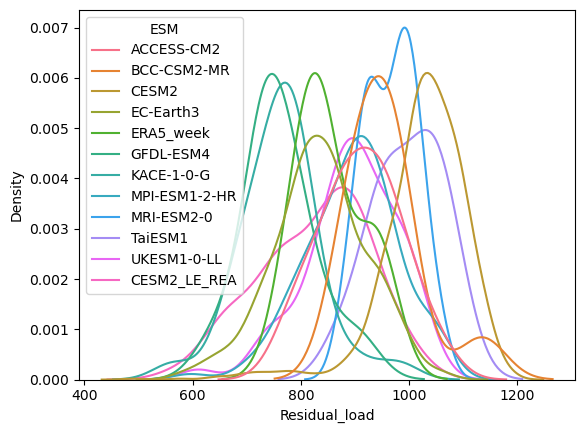

In [13]:
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure()
sns.kdeplot(
    data=df_combined,
    x="Residual_load",
    hue="ESM",
    common_norm=False
)

plt.show()

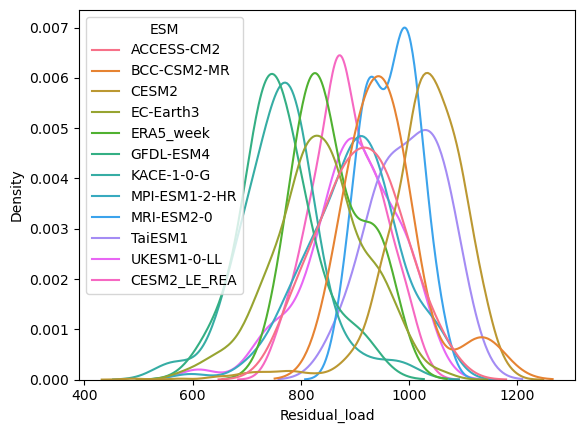

In [12]:
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure()
sns.kdeplot(
    data=df_combined,
    x="Residual_load",
    hue="ESM",
    common_norm=False
)

plt.show()

In [14]:
ts_seasonal_mean.values.flatten()

array([ 759.52527892,  965.91945379,  903.9082295 , ...,  930.11451336,
        824.62681217, 1005.44297479])

In [13]:
# Flatten: combine all ESM_runs per season if needed
# values = ts_seasonal_mean.values.flatten()
values = df_combined['Residual_load'].values

# Sort descending
sorted_vals = np.sort(values)[::-1]

# Empirical probability (rank / total)
prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

In [28]:
len(prob)

2249

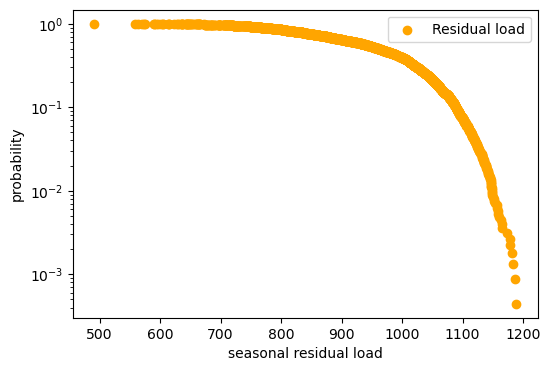

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(sorted_vals, prob, color="orange", label="Residual load")
plt.yscale("log")   # log-scale for probability
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend()
plt.show()

In [17]:
ts_seasonal_mean.sel(ESM_run='ACCESS-CM2_r1i1p1f1')['ESM'].values.item()

'ACCESS-CM2'

In [18]:
df_combined.where(df_combined['ESM_run'] == 'ACCESS-CM2_r1i1p1f1')['ESM'].dropna()[0]

'ACCESS-CM2'

In [19]:
df_combined

,season,ESM_run,crs,gridtype,ESM,run,country,period,Residual_load
0,1,ACCESS-CM2_r1i1p1f1,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,759.525279
1,1,ACCESS-CM2_r4i1p1f1,4326,lonlat,ACCESS-CM2,r4i1p1f1,9.0,week,965.919454
2,1,ACCESS-CM2_r5i1p1f1,4326,lonlat,ACCESS-CM2,r5i1p1f1,9.0,week,903.908229
3,1,BCC-CSM2-MR_r1i1p1f1,4326,lonlat,BCC-CSM2-MR,r1i1p1f1,9.0,week,1134.775641
4,1,CESM2_LE2-1001_001,4326,lonlat,CESM2,LE2-1001_001,9.0,week,1034.448522
...,...,...,...,...,...,...,...,...,...
2244,12,CESM2_LE_REA_ens026,4326,lonlat,CESM2_LE_REA,ens026,9.0,week,977.001650
2245,12,CESM2_LE_REA_ens011,4326,lonlat,CESM2_LE_REA,ens011,9.0,week,898.790536
2246,12,CESM2_LE_REA_ens050,4326,lonlat,CESM2_LE_REA,ens050,9.0,week,881.545249
2247,12,CESM2_LE_REA_ens032,4326,lonlat,CESM2_LE_REA,ens032,9.0,week,889.083882


In [20]:
df_combined.where(df_combined['ESM_run'] == 'ACCESS-CM2_r4i1p1f1')['ESM'].dropna().values[0]

'ACCESS-CM2'

In [15]:
esm_coords = []
values = []
for esm_run, group in df_combined.groupby('ESM_run'):
    print(f"ESM_run: {esm_run}")
    esm_value = group['ESM'].iloc[0]
    print(esm_value)
    # print(group['Residual_load'])
    for esm_val in group['Residual_load'].dropna():
        print(esm_val)
        values.append(esm_val)
        esm_coords.append(esm_value)
    # break

print(esm_coords)
print(values)

ESM_run: ACCESS-CM2_r1i1p1f1
ACCESS-CM2
759.525278920878
812.943530585475
1005.6839824471367
959.9787055739364
943.0555822362918
948.4772789091937
917.1522569586004
852.1516253337587
995.8215515394377
878.447398004959
954.163767646351
ESM_run: ACCESS-CM2_r4i1p1f1
ACCESS-CM2
965.9194537891401
1023.503234061978
791.6639015255382
966.7285496952492
863.1010915115854
1067.3087544025561
921.0786469756773
858.7638692177287
975.7339573139835
794.1064849079443
887.805461922158
ESM_run: ACCESS-CM2_r5i1p1f1
ACCESS-CM2
903.9082294970841
850.6498292539035
803.4931481857127
835.696464725042
890.9985450859456
875.3280310304654
908.2874381902978
946.591168939214
898.9010681221769
930.5894414447417
1030.5599626541546
ESM_run: BCC-CSM2-MR_r1i1p1f1
BCC-CSM2-MR
1134.7756405107577
968.365650607435
985.5151559393727
956.8813719505355
967.8162790152002
919.3491872897048
915.5770041011829
881.6569369806307
982.3250800768783
920.9197453535729
881.6147185268228
ESM_run: CESM2_LE2-1001_001
CESM2
1034.44852226183

In [16]:
esm_coords = []
values = []

for esm_run, group in df_combined.groupby('ESM_run'):
    # print(f"Processing ESM_run: {esm_run}")
    
    esm_value = group['ESM'].iloc[0]
    
    for esm_val in group['Residual_load'].dropna():
        values.append(esm_val)
        esm_coords.append(esm_value)

In [ ]:
# Flatten values but keep track of which ESM they come from
# esm_coords = []
# values = []
# for esm_run in df_combined['ESM_run']:
#     print(f"Processing ESM_run: {esm_run}")
#     for esm_val in df_combined.where(df_combined['ESM_run'] == esm_run)['Residual_load'].dropna():
#         values.append(esm_val)
#         esm_coords.append(df_combined.where(df_combined['ESM_run'] == esm_run)['ESM'].dropna().values[0])
# print(esm_coords)

Processing ESM_run: ACCESS-CM2_r1i1p1f1
Processing ESM_run: ACCESS-CM2_r4i1p1f1
Processing ESM_run: ACCESS-CM2_r5i1p1f1
Processing ESM_run: BCC-CSM2-MR_r1i1p1f1
Processing ESM_run: CESM2_LE2-1001_001
Processing ESM_run: CESM2_LE2-1011_001
Processing ESM_run: CESM2_LE2-1021_002
Processing ESM_run: CESM2_LE2-1031_002
Processing ESM_run: CESM2_LE2-1041_003
Processing ESM_run: CESM2_LE2-1051_003
Processing ESM_run: CESM2_LE2-1061_004
Processing ESM_run: CESM2_LE2-1071_004
Processing ESM_run: CESM2_LE2-1081_005
Processing ESM_run: CESM2_LE2-1091_005
Processing ESM_run: CESM2_LE2-1101_006
Processing ESM_run: CESM2_LE2-1111_006
Processing ESM_run: CESM2_LE2-1121_007
Processing ESM_run: CESM2_LE2-1131_007
Processing ESM_run: CESM2_LE2-1141_008
Processing ESM_run: CESM2_LE2-1151_008
Processing ESM_run: CESM2_LE2-1161_009
Processing ESM_run: CESM2_LE2-1171_009
Processing ESM_run: CESM2_LE2-1181_010
Processing ESM_run: CESM2_LE2-1191_010
Processing ESM_run: CESM2_LE2-1231_001
Processing ESM_run: 

In [ ]:
type(sorted_indices)
# len(values)
sorted_indices

array([1133,  851,  704, ..., 1631, 1931, 1270])

In [29]:
# Flatten values but keep track of which ESM they come from
# esm_coords = []
# values = []

# for esm_run in df_combined['ESM_run']:
#     for esm_val in df_combined.where(df_combined['ESM_run'] == esm_run)['Residual_load'].dropna():
#         values.append(esm_val)
#         esm_coords.append(df_combined.where(df_combined['ESM_run'] == esm_run)['ESM'].dropna().values[0])

# values = np.array(values)
# esm_coords = np.array(esm_coords)

esm_coords = []
values = []

for esm_run, group in df_combined.groupby('ESM_run'):
    # print(f"Processing ESM_run: {esm_run}")
    
    esm_value = group['ESM'].iloc[0]
    
    for esm_val in group['Residual_load'].dropna():
        values.append(esm_val)
        esm_coords.append(esm_value)

values = np.array(values)
esm_coords = np.array(esm_coords)

# Sort descending
order = np.argsort(-values)
sorted_vals = values[order]
sorted_esm = esm_coords[order]

# Make array of colours for each ESM
unique_esms = np.unique(sorted_esm)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_esms)))
esm_color_map = {esm: colors[i] for i, esm in enumerate(unique_esms)}
point_colors = [esm_color_map[esm] for esm in sorted_esm]

# Empirical probability
prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

In [23]:
print(len(prob))

2249


In [18]:
# Flatten values but keep track of which ESM they come from
esm_coords = []
values = []

for esm_run in ts_seasonal_mean['ESM_run']:
    for esm_val in ts_seasonal_mean.sel(ESM_run=esm_run).values.flatten():
        values.append(esm_val)
        esm_coords.append(ts_seasonal_mean.sel(ESM_run=esm_run)['ESM'].values.item())

values = np.array(values)
esm_coords = np.array(esm_coords)

# Sort values descending but keep indices to track ESM
sorted_indices = np.argsort(values)[::-1]
sorted_vals = values[sorted_indices]
sorted_esm = esm_coords[sorted_indices]

# Make array of colours for each ESM
unique_esms = np.unique(sorted_esm)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_esms)))
esm_color_map = {esm: colors[i] for i, esm in enumerate(unique_esms)}
point_colors = [esm_color_map[esm] for esm in sorted_esm]

# Empirical probability
prob_2 = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
# prob

In [19]:
# Flatten values but keep track of which ESM they come from
esm_coords = []
values = []

for esm_run in ts_seasonal_mean['ESM_run']:
    for esm_val in ts_seasonal_mean.sel(ESM_run=esm_run).values.flatten():
        values.append(esm_val)
        esm_coords.append(ts_seasonal_mean.sel(ESM_run=esm_run)['ESM'].values.item())
        # break
    break
print(esm_coords)
print(values)
print(len(esm_coords))
print(len(values))

['ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2']
[np.float64(759.525278920878), np.float64(812.943530585475), np.float64(1005.6839824471367), np.float64(959.9787055739364), np.float64(943.0555822362918), np.float64(948.4772789091937), np.float64(917.1522569586004), np.float64(852.1516253337587), np.float64(995.8215515394377), np.float64(878.447398004959), np.float64(954.163767646351)]
11
11


In [30]:
print(len(sorted_vals))
print(len(prob))

2249
2249


/tmp/ipykernel_783615/1369278331.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)


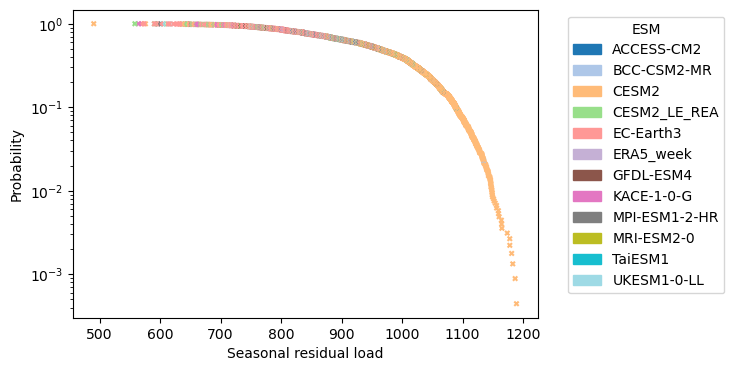

In [31]:
# Example structure:
# ts_seasonal_mean is a xarray DataArray or pandas DataFrame
# dimensions: ('ESM_run', 'season') or similar
# 'ESM' coordinate exists: ts_seasonal_mean['ESM']


# Plot, coloring by ESM
plt.figure(figsize=(6,4))
scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)
plt.yscale("log")
plt.xlabel("Seasonal residual load")
plt.ylabel("Probability")
# Create legend patches for each ESM
patches = [mpatches.Patch(color=esm_color_map[esm], label=esm) for esm in unique_esms]
plt.legend(handles=patches, title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_783615/1369278331.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)


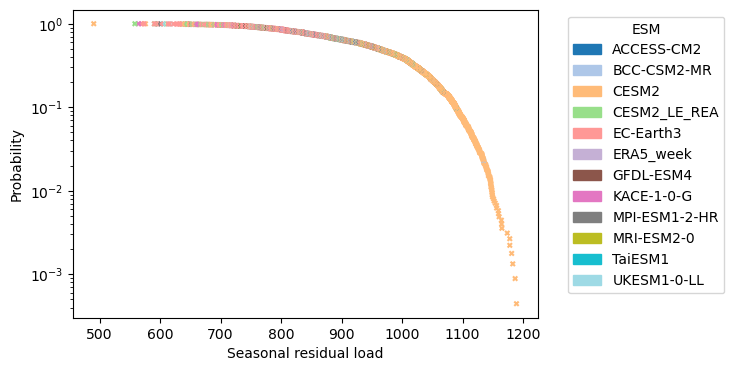

In [32]:
# Example structure:
# ts_seasonal_mean is a xarray DataArray or pandas DataFrame
# dimensions: ('ESM_run', 'season') or similar
# 'ESM' coordinate exists: ts_seasonal_mean['ESM']


# Plot, coloring by ESM
plt.figure(figsize=(6,4))
scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)
plt.yscale("log")
plt.xlabel("Seasonal residual load")
plt.ylabel("Probability")
# Create legend patches for each ESM
patches = [mpatches.Patch(color=esm_color_map[esm], label=esm) for esm in unique_esms]
plt.legend(handles=patches, title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_2055328/4104426604.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)


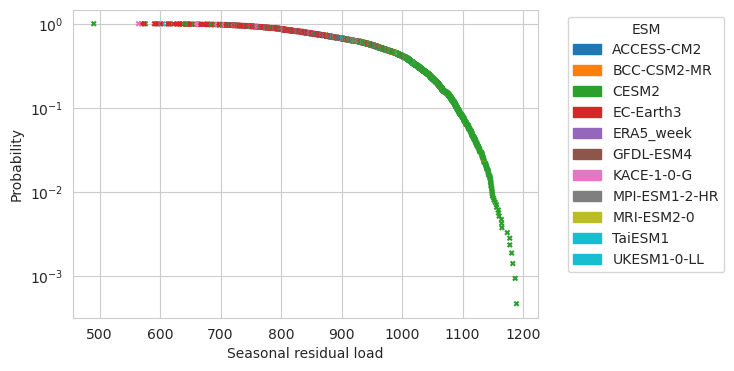

In [ ]:
# Example structure:
# ts_seasonal_mean is a xarray DataArray or pandas DataFrame
# dimensions: ('ESM_run', 'season') or similar
# 'ESM' coordinate exists: ts_seasonal_mean['ESM']


# Plot, coloring by ESM
plt.figure(figsize=(6,4))
scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)
plt.yscale("log")
plt.xlabel("Seasonal residual load")
plt.ylabel("Probability")
# Create legend patches for each ESM
patches = [mpatches.Patch(color=esm_color_map[esm], label=esm) for esm in unique_esms]
plt.legend(handles=patches, title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

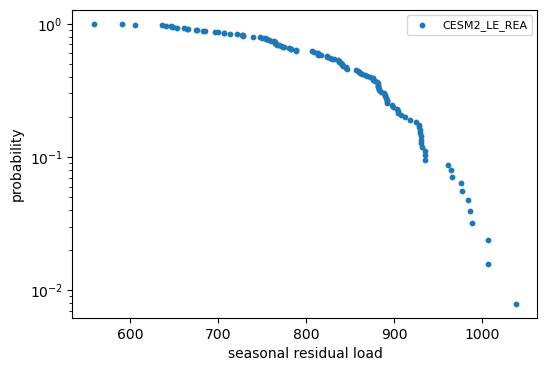

In [33]:
plt.figure(figsize=(6,4))
for esm in np.array(['CESM2_LE_REA']):
# for esm in np.unique(ts_seasonal_mean.ESM.values):

    # vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
    vals = df_combined.where(df_combined['ESM'] == esm)['Residual_load'].dropna().values.flatten()
    sorted_vals = np.sort(vals)[::-1]
    prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.scatter(sorted_vals, prob, label=esm, s=10)  # s=10 for smaller points

plt.yscale("log")
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend(ncol=2, fontsize=8)
plt.show()

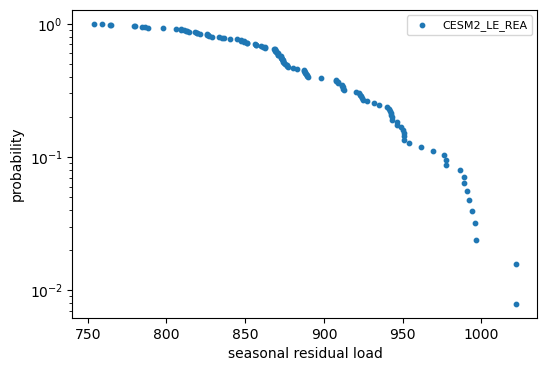

In [51]:
plt.figure(figsize=(6,4))
for esm in np.array(['CESM2_LE_REA']):
# for esm in np.unique(ts_seasonal_mean.ESM.values):

    # vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
    vals = df_combined.where(df_combined['ESM'] == esm)['Residual_load'].dropna().values.flatten()
    sorted_vals = np.sort(vals)[::-1]
    prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.scatter(sorted_vals, prob, label=esm, s=10)  # s=10 for smaller points

plt.yscale("log")
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend(ncol=2, fontsize=8)
plt.show()

In [29]:
len(vals)
max(vals)

np.float64(1038.644838442943)

In [30]:
tst = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
# Remove nans
tst = tst[~np.isnan(tst)]
len(tst)

0

In [31]:
len(np.unique(ts_seasonal_mean.ESM.values))

11

In [32]:
len(df_combined.where(df_combined['ESM'] == 'CESM2')['Residual_load'].dropna().values.flatten())

1133

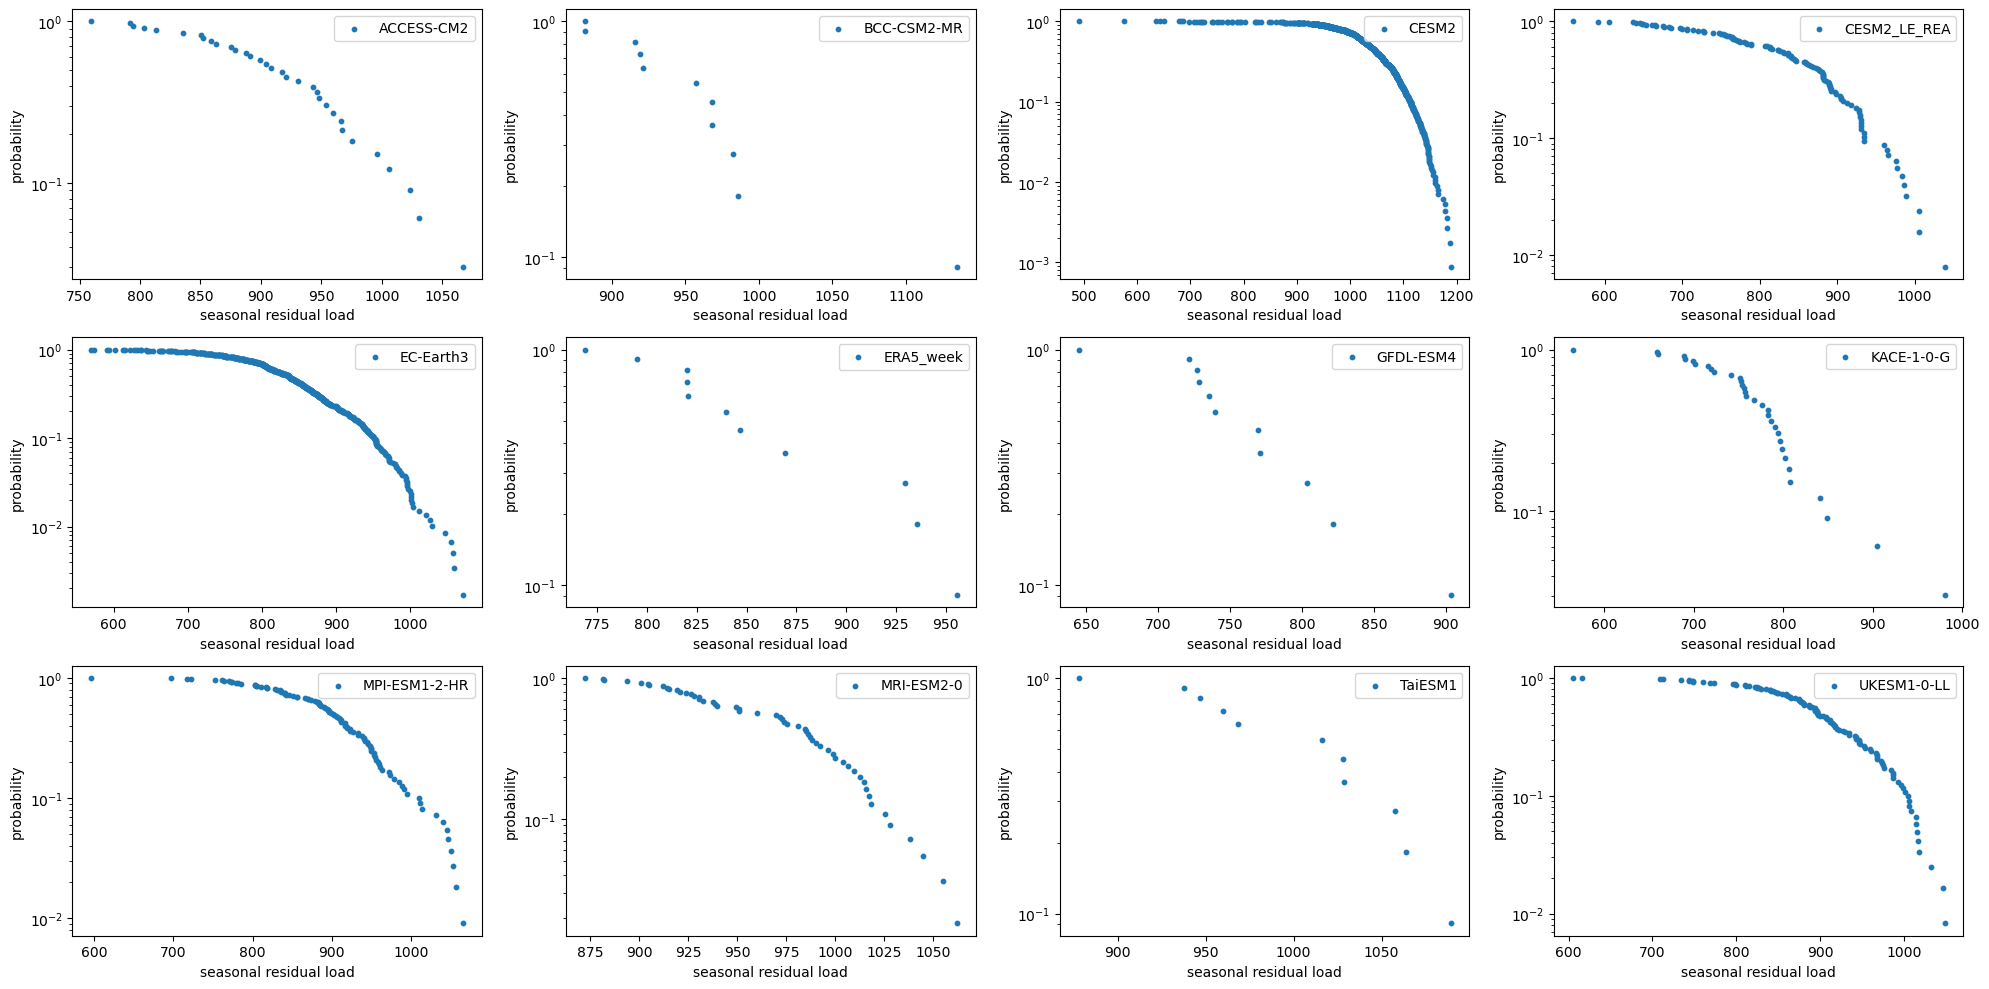

In [34]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
for i in range(3):
    for j in range(4):
        idx = i*4 + j
        if idx < len(unique_esms):
            esm = unique_esms[idx]
            vals = df_combined.where(df_combined['ESM'] == esm)['Residual_load'].dropna().values.flatten()
            # vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
            sorted_vals = np.sort(vals)[::-1]
            prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
            axes[i, j].scatter(sorted_vals, prob, label=esm, s=10)
            axes[i, j].set_yscale("log")
            axes[i, j].set_xlabel("seasonal residual load")
            axes[i, j].set_ylabel("probability")
            axes[i, j].legend()
plt.tight_layout()
plt.show()

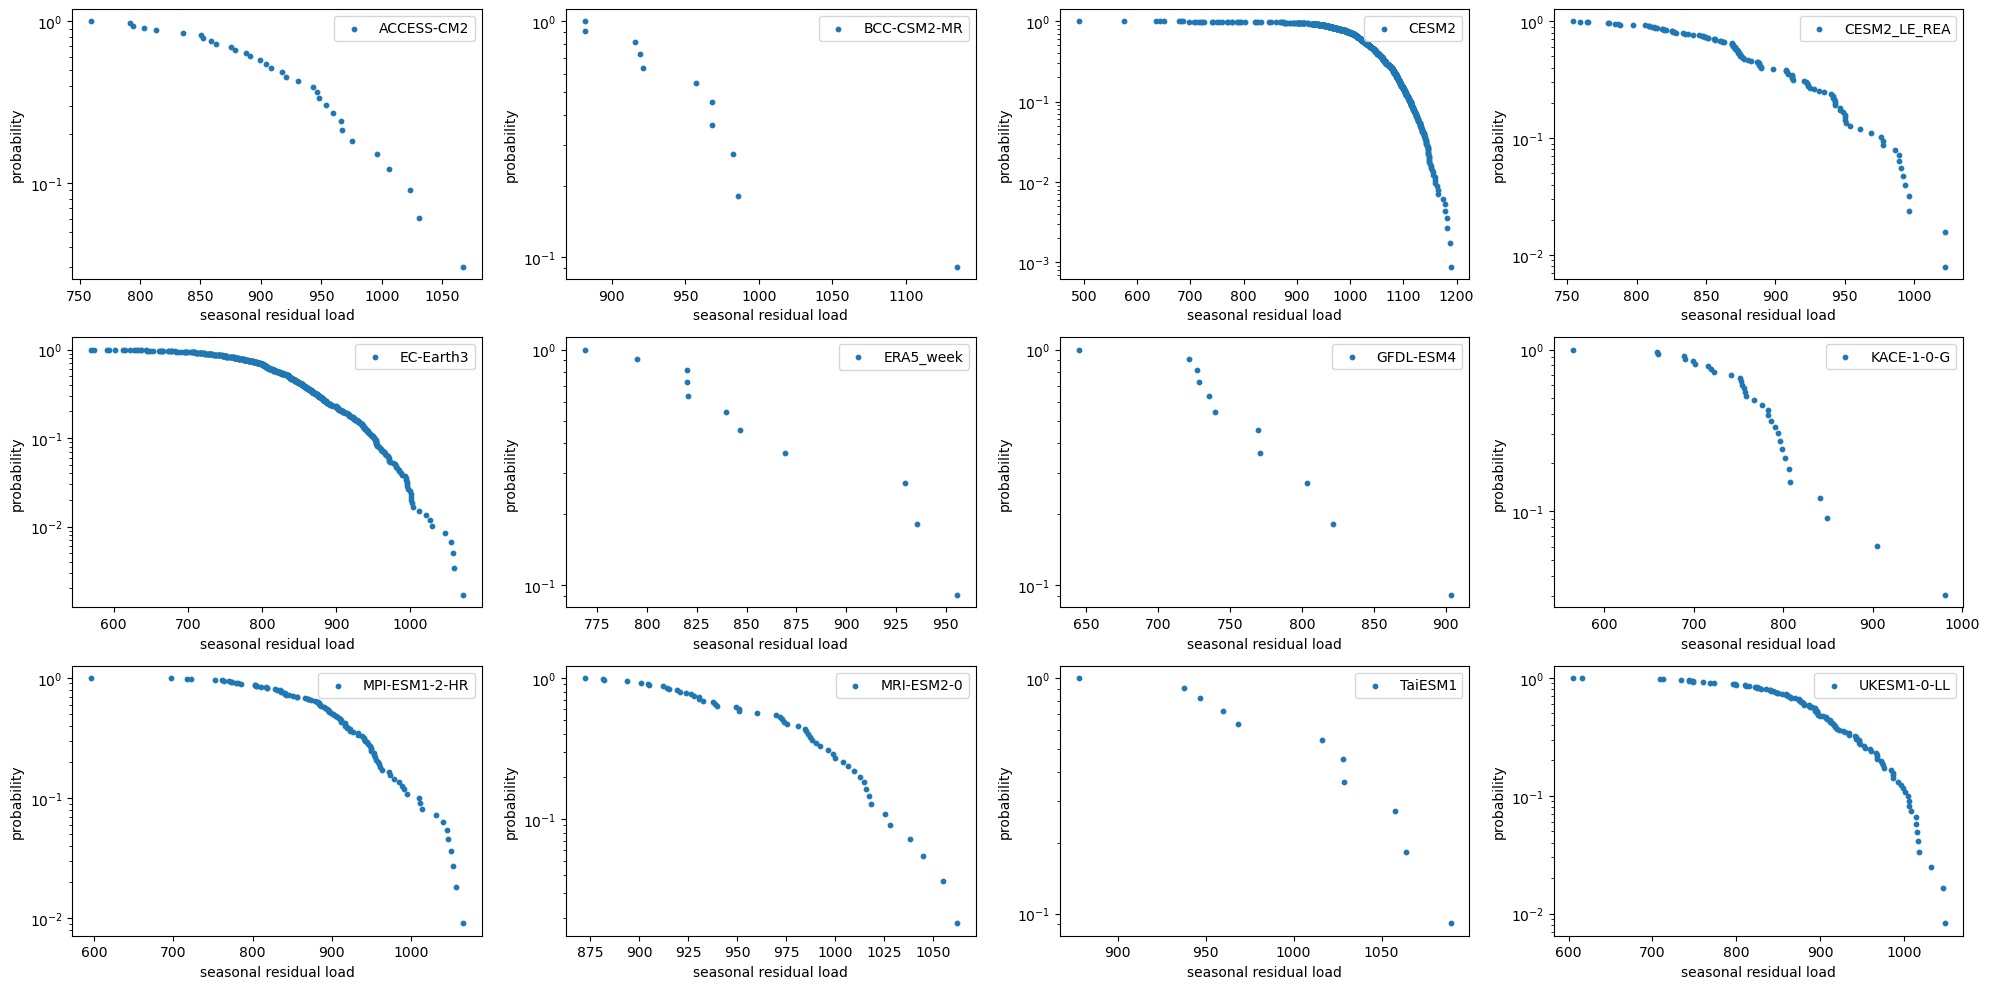

In [50]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
for i in range(3):
    for j in range(4):
        idx = i*4 + j
        if idx < len(unique_esms):
            esm = unique_esms[idx]
            vals = df_combined.where(df_combined['ESM'] == esm)['Residual_load'].dropna().values.flatten()
            # vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
            sorted_vals = np.sort(vals)[::-1]
            prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
            axes[i, j].scatter(sorted_vals, prob, label=esm, s=10)
            axes[i, j].set_yscale("log")
            axes[i, j].set_xlabel("seasonal residual load")
            axes[i, j].set_ylabel("probability")
            axes[i, j].legend()
plt.tight_layout()
plt.show()

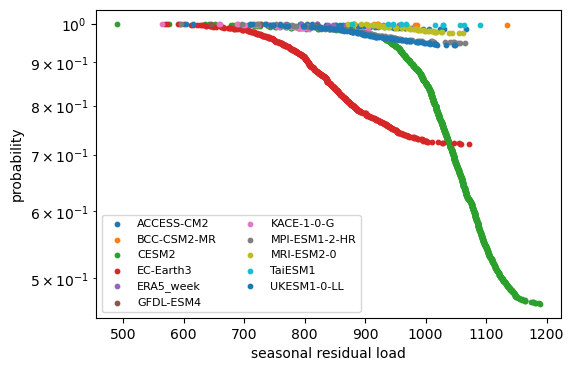

In [34]:
plt.figure(figsize=(6,4))
for esm in np.unique(ts_seasonal_mean.ESM.values):
    vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
    sorted_vals = np.sort(vals)[::-1]
    prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.scatter(sorted_vals, prob, label=esm, s=10)  # s=10 for smaller points

plt.yscale("log")
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend(ncol=2, fontsize=8)
plt.show()

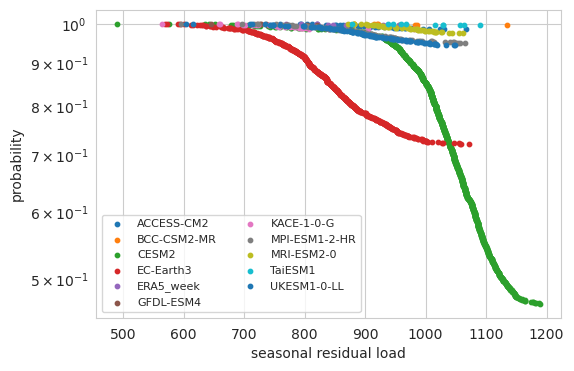

In [97]:
plt.figure(figsize=(6,4))
for esm in np.unique(ts_seasonal_mean.ESM.values):
    vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
    sorted_vals = np.sort(vals)[::-1]
    prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.scatter(sorted_vals, prob, label=esm, s=10)  # s=10 for smaller points

plt.yscale("log")
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend(ncol=2, fontsize=8)
plt.show()

In [103]:
5*(10**-1)

0.5

# Look at seasonal distribution of RL in REA data

In [29]:
ds_REA

<xarray.Dataset> Size: 2MB
Dimensions:        (ESM_run: 126, time: 154)
Coordinates:
    sim            (ESM_run) <U90 45kB 'c2.033.031.029.027.028.033.035.038.03...
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            (ESM_run) <U6 3kB 'ens058' 'ens056' ... 'ens032' 'ens087'
  * ESM_run        (ESM_run) <U19 10kB 'CESM2_LE_REA_ens058' ... 'CESM2_LE_RE...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    demand         (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    rsds           (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    tas            (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    tasmax         (ESM_run, time) float32 78kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    Netto          (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 155kB dask.array<chunksize=(1, 154), meta=np.ndarray>

In [38]:
# Calculate the mean for all ESM_runs
ds_REA_mean = ds_REA.mean(dim='ESM_run')



In [35]:
ds_REA_20d = ds_REA.rolling(time=30, center=True).mean()

Slope of mean trend: -0.9499 per day


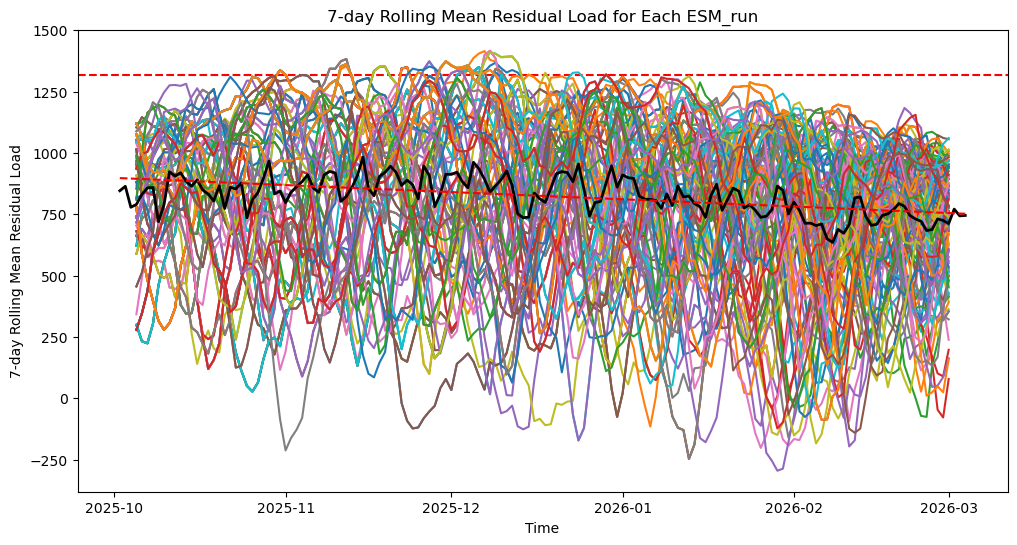

In [51]:
# Plot timeseries of residual load for each ESM_run
plt.figure(figsize=(12, 6))
# Add threshold line at np.float64(1319.138650687668)
plt.axhline(y=1319.138650687668, color='red', linestyle='--', label='Threshold')

for esm_run in ds_REA['ESM_run']:
    plt.plot(ds_REA_7d.sel(ESM_run=esm_run)['time'], ds_REA_7d.sel(ESM_run=esm_run)['Residual_load'], label=esm_run)
plt.plot(ds_REA_mean['time'], ds_REA_mean['Residual_load'], label='Mean', color='black', linewidth=2)
# Regression line for mean
time = ds_REA_mean['time'].values
time_days = (time - time[0]) / np.timedelta64(1, 'D')

z = np.polyfit(time_days, ds_REA_mean['Residual_load'].values, 1)
p = np.poly1d(z)

plt.plot(ds_REA_mean['time'], p(time_days), label='Mean Trend', color='red', linestyle='--')

print(f"Slope of mean trend: {z[0]:.4f} per day")

plt.xlabel('Time')
plt.ylabel('7-day Rolling Mean Residual Load')
plt.title('7-day Rolling Mean Residual Load for Each ESM_run')
# plt.legend()
plt.show()

In [47]:
154*z[0]

np.float64(-1.6930853800832674e-12)

In [45]:
z

array([-1.09940609e-14,  2.02397724e+04])

In [44]:
p(ds_REA_mean['time'].values.astype(float))

array([897.22623883, 896.27635197, 895.32646511, 894.37657825,
       893.42669138, 892.47680452, 891.52691766, 890.5770308 ,
       889.62714393, 888.67725707, 887.72737021, 886.77748334,
       885.82759648, 884.87770962, 883.92782276, 882.97793589,
       882.02804903, 881.07816217, 880.12827531, 879.17838844,
       878.22850158, 877.27861472, 876.32872786, 875.37884099,
       874.42895413, 873.47906727, 872.52918041, 871.57929354,
       870.62940668, 869.67951982, 868.72963296, 867.77974609,
       866.82985923, 865.87997237, 864.93008551, 863.98019864,
       863.03031178, 862.08042492, 861.13053805, 860.18065119,
       859.23076433, 858.28087747, 857.3309906 , 856.38110374,
       855.43121688, 854.48133002, 853.53144315, 852.58155629,
       851.63166943, 850.68178257, 849.7318957 , 848.78200884,
       847.83212198, 846.88223512, 845.93234825, 844.98246139,
       844.03257453, 843.08268767, 842.1328008 , 841.18291394,
       840.23302708, 839.28314022, 838.33325335, 837.38